# Оценка качества датасетов

Этот блокнот анализирует все доступные датасеты и выявляет потенциальные проблемы:
- дубликаты, конфликтные метки, распределение классов, длины текстов,
- языковое распределение, пересечение train/test и др.

## Импорт необходимых библиотек

In [1]:
import json
import os
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
import sys
sys.path.append('..')

## 1. Загрузка всех источников данных

In [3]:
sources = {}

In [4]:
if os.path.exists('../data/preprocessed.csv'):
    sources['preprocessed'] = pd.read_csv('../data/preprocessed.csv', index_col=0)
    print(f"preprocessed: {len(sources['preprocessed'])} записей")

preprocessed: 58067 записей


Тестовый набор чистых сообщений

In [5]:
if os.path.exists('../data/test_clear.json'):
    sources['test_clear'] = pd.read_json('../data/test_clear.json')
    print(f"test_clear: {len(sources['test_clear'])} записей")

test_clear: 25274 записей


Предобработанный датасет

In [6]:
if os.path.exists('../data/preprocessed.csv'):
    sources['preprocessed'] = pd.read_csv('../data/preprocessed.csv', index_col=0)
    print(f"preprocessed: {len(sources['preprocessed'])} записей")

preprocessed: 58067 записей


Объединённый тренировочный набор

In [7]:
train_sources = [k for k in ['preprocessed'] if k in sources]

In [8]:
if train_sources:
    df_train = pd.concat([sources[k] for k in train_sources], ignore_index=True)
    print(f"\nОбъединённый тренировочный набор: {len(df_train)} записей")
else:
    df_train = pd.DataFrame(columns=['text', 'label'])
    print("Тренировочные данные не найдены")


Объединённый тренировочный набор: 58067 записей


Объединённый тестовый набор

In [9]:
test_sources = [k for k in ['test_clear', 'lols_2023'] if k in sources]

In [10]:
if test_sources:
    df_test = pd.concat([sources[k] for k in test_sources], ignore_index=True)
    print(f"Объединённый тестовый набор: {len(df_test)} записей")
else:
    df_test = pd.DataFrame(columns=['text', 'label'])
    print("Тестовые данные не найдены")

Объединённый тестовый набор: 25274 записей


## 2. Статистика распределения классов

In [11]:
for name, df in [("Тренировочный", df_train), ("Тестовый", df_test)]:
    if df.empty:
        continue
    ham = len(df[df['label'] == 0])
    spam = len(df[df['label'] == 1])
    total = len(df)
    ratio = spam / ham if ham > 0 else float('inf')
    print(f"\n{name} набор ({total} записей):")
    print(f"  Ham (0):  {ham:>6} ({ham/total*100:.1f}%)")
    print(f"  Spam (1): {spam:>6} ({spam/total*100:.1f}%)")
    print(f"  Соотношение spam/ham: {ratio:.2f}")


Тренировочный набор (58067 записей):
  Ham (0):   33601 (57.9%)
  Spam (1):  24466 (42.1%)
  Соотношение spam/ham: 0.73

Тестовый набор (25274 записей):
  Ham (0):   25274 (100.0%)
  Spam (1):      0 (0.0%)
  Соотношение spam/ham: 0.00


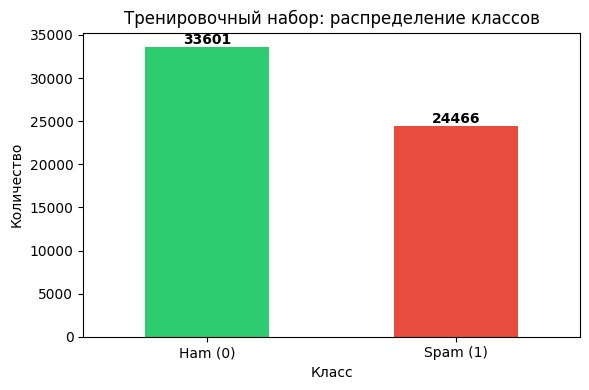

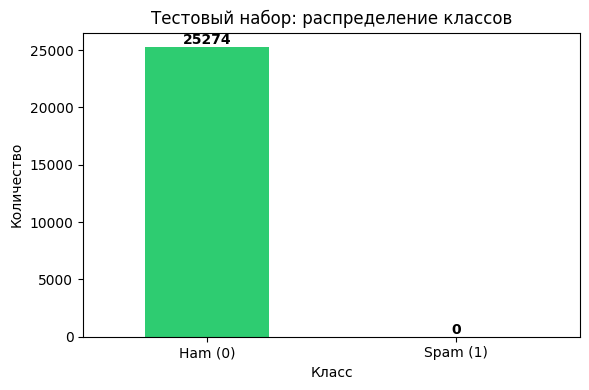

In [13]:
for name, df in [("Тренировочный", df_train), ("Тестовый", df_test)]:
    if df.empty:
        continue

    fig, ax = plt.subplots(figsize=(6, 4))

    counts = df['label'].value_counts().reindex([0, 1], fill_value=0)
    counts.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])

    ax.set_title(f'{name} набор: распределение классов')
    ax.set_xlabel('Класс')
    ax.set_ylabel('Количество')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Ham (0)', 'Spam (1)'], rotation=0)

    ymax = max(counts.max(), 1)
    for i, v in enumerate(counts):
        ax.text(i, v + ymax * 0.01, str(v), ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

In [14]:
print("\nРаспределение по источникам:")
for name in train_sources:
    df = sources[name]
    ham = len(df[df['label'] == 0])
    spam = len(df[df['label'] == 1])
    print(f"  {name:>12}: ham={ham:>5}, spam={spam:>5}, total={len(df):>5}")


Распределение по источникам:
  preprocessed: ham=33601, spam=24466, total=58067


## 3. Анализ длин текстов

In [15]:
for name, df in [("Тренировочный", df_train), ("Тестовый", df_test)]:
    if df.empty:
        continue
    df_copy = df.copy()
    df_copy['text_length'] = df_copy['text'].str.len()

    print(f"\n{name} набор:")
    for label, label_name in [(0, 'Ham'), (1, 'Spam')]:
        subset = df_copy[df_copy['label'] == label]['text_length']
        if subset.empty:
            continue
        print(f"  {label_name}:")
        print(f"    min={subset.min()}, max={subset.max()}, "
              f"mean={subset.mean():.1f}, median={subset.median():.1f}, "
              f"std={subset.std():.1f}")


Тренировочный набор:
  Ham:
    min=3, max=2876, mean=49.7, median=29.0, std=87.6
  Spam:
    min=3, max=4110, mean=354.4, median=228.0, std=396.5

Тестовый набор:
  Ham:
    min=1, max=1712, mean=80.8, median=59.0, std=88.1


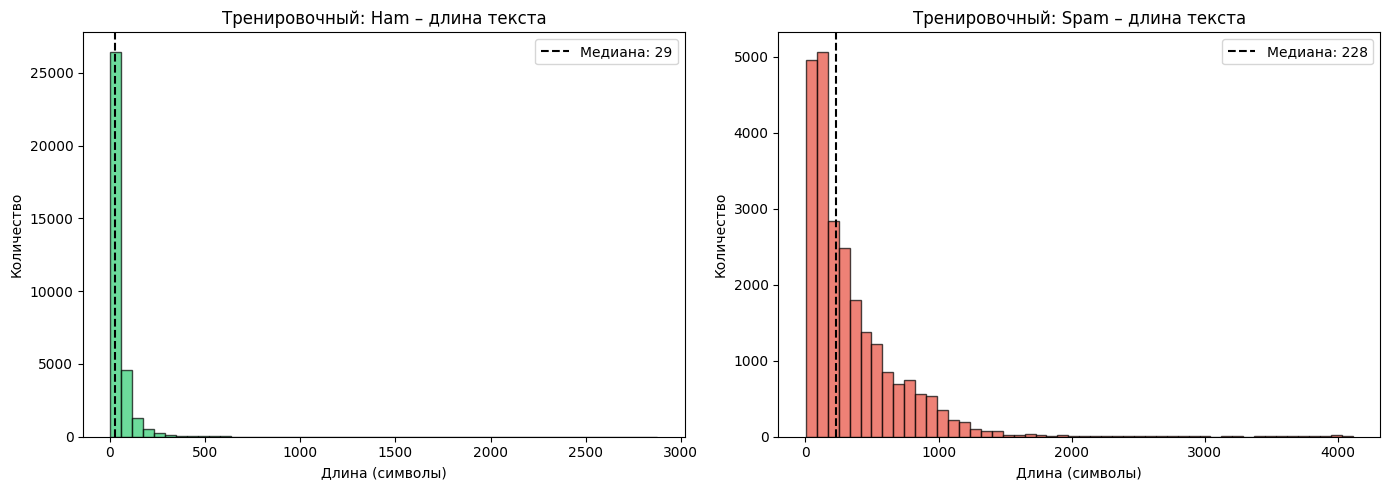

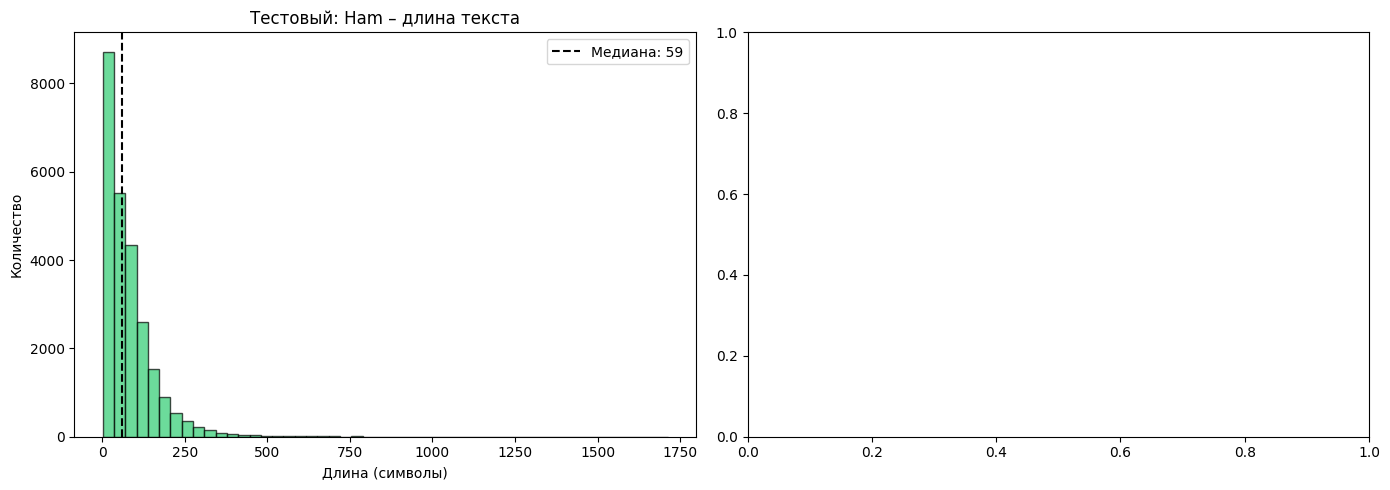

In [16]:
for name, df in [("Тренировочный", df_train), ("Тестовый", df_test)]:
    if df.empty:
        continue
    df_copy = df.copy()
    df_copy['text_length'] = df_copy['text'].str.len()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for idx, (label, label_name, color) in enumerate([(0, 'Ham', '#2ecc71'), (1, 'Spam', '#e74c3c')]):
        subset = df_copy[df_copy['label'] == label]['text_length']
        if subset.empty:
            continue
        axes[idx].hist(subset, bins=50, color=color, alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'{name}: {label_name} – длина текста')
        axes[idx].set_xlabel('Длина (символы)')
        axes[idx].set_ylabel('Количество')
        axes[idx].axvline(subset.median(), color='black', linestyle='--', label=f'Медиана: {subset.median():.0f}')
        axes[idx].legend()
    plt.tight_layout()
    plt.show()

## 4. Обнаружение дубликатов

In [17]:
def find_duplicates(df, name=""):
    """Поиск точных дубликатов по полю text."""
    if df.empty:
        return
    total = len(df)
    unique = df['text'].nunique()
    dupes = total - unique
    print(f"\n{name}:")
    print(f"  Всего записей:     {total}")
    print(f"  Уникальных текстов: {unique}")
    print(f"  Точных дубликатов:  {dupes} ({dupes/total*100:.1f}%)")

    if dupes > 0:
        dup_texts = df[df.duplicated(subset='text', keep=False)]
        dup_groups = dup_texts.groupby('text')['label'].agg(['count', 'nunique'])
        print(f"  Групп дубликатов:   {len(dup_groups)}")

        top_dupes = dup_groups.sort_values('count', ascending=False).head(5)
        print(f"\n  Топ-5 дубликатов:")
        for text_val, row in top_dupes.iterrows():
            preview = text_val[:80].replace('\n', ' ')
            print(f"    [{row['count']}x] \"{preview}...\"")
    return dupes

In [18]:
train_dupes = find_duplicates(df_train, "Тренировочный набор")


Тренировочный набор:
  Всего записей:     58067
  Уникальных текстов: 58067
  Точных дубликатов:  0 (0.0%)


In [19]:
test_dupes = find_duplicates(df_test, "Тестовый набор")


Тестовый набор:
  Всего записей:     25274
  Уникальных текстов: 22806
  Точных дубликатов:  2468 (9.8%)
  Групп дубликатов:   520

  Топ-5 дубликатов:
    [326x] "Спасибо..."
    [225x] "Спасибо!..."
    [134x] "Да..."
    [72x] "Спасибо большое!..."
    [64x] "Спасибо большое..."


### Near-дубликаты (нормализованные)

In [20]:
def normalize_for_dedup(text):
    """Нормализация текста для поиска near-дубликатов."""
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text

In [21]:
for name, df in [("Тренировочный", df_train), ("Тестовый", df_test)]:
    if df.empty:
        continue
    df_copy = df.copy()
    df_copy['text_normalized'] = df_copy['text'].apply(normalize_for_dedup)
    total = len(df_copy)
    unique_norm = df_copy['text_normalized'].nunique()
    near_dupes = total - unique_norm
    print(f"\n{name}: near-дубликатов (после нормализации): {near_dupes} ({near_dupes/total*100:.1f}%)")


Тренировочный: near-дубликатов (после нормализации): 1338 (2.3%)

Тестовый: near-дубликатов (после нормализации): 3380 (13.4%)


## 5. Конфликтные метки

In [22]:
for name, df in [("Тренировочный", df_train), ("Тестовый", df_test)]:
    if df.empty:
        continue
    label_groups = df.groupby('text')['label'].nunique()
    conflicts = label_groups[label_groups > 1]
    print(f"\n{name}: {len(conflicts)} текстов с разными метками")

    if len(conflicts) > 0:
        conflict_texts = df[df['text'].isin(conflicts.index)]
        print(f"\nПримеры конфликтов:")
        for text_val in list(conflicts.index)[:5]:
            labels = df[df['text'] == text_val]['label'].tolist()
            preview = text_val[:80].replace('\n', ' ')
            print(f"  \"{preview}...\" → метки: {labels}")


Тренировочный: 0 текстов с разными метками

Тестовый: 0 текстов с разными метками


## 6. Пустые и короткие тексты

In [23]:
for name, df in [("Тренировочный", df_train), ("Тестовый", df_test)]:
    if df.empty:
        continue
    null_count = df['text'].isna().sum()
    empty_count = (df['text'].str.strip() == '').sum() if not df['text'].isna().all() else 0
    short_count = (df['text'].str.len() < 5).sum()
    very_short = df[df['text'].str.len() < 5]

    print(f"\n{name}:")
    print(f"  NaN:            {null_count}")
    print(f"  Пустые:         {empty_count}")
    print(f"  Короткие (<5):  {short_count}")

    if len(very_short) > 0:
        print(f"\n  Примеры коротких:")
        for _, row in very_short.head(10).iterrows():
            print(f"    [{row['label']}] \"{row['text']}\"")


Тренировочный:
  NaN:            0
  Пустые:         0
  Короткие (<5):  582

  Примеры коротких:
    [0] "Майн"
    [0] "Жиз"
    [0] "тут?"
    [0] "ало"
    [0] "Угу!"
    [0] "ааа"
    [0] "207"
    [0] "255"
    [0] "ура"
    [0] "лучш"

Тестовый:
  NaN:            0
  Пустые:         0
  Короткие (<5):  856

  Примеры коротких:
    [0] "."
    [0] "++++"
    [0] "…"
    [0] "👍"
    [0] "😊"
    [0] "👍"
    [0] "++"
    [0] "🍀"
    [0] "/40"
    [0] "👍"


## 7. Языковое распределение

In [24]:
try:
    from langdetect import detect, LangDetectException

    def safe_detect(text):
        try:
            if not text or len(text.strip()) < 3:
                return 'unknown'
            return detect(text)
        except (LangDetectException, Exception):
            return 'unknown'

    for name, df in [("Тренировочный", df_train), ("Тестовый", df_test)]:
        if df.empty:
            continue
        sample = df.sample(min(2000, len(df)), random_state=42)
        sample_langs = sample['text'].apply(safe_detect)
        lang_counts = Counter(sample_langs)
        total_sample = len(sample)

        print(f"\n{name} (выборка {total_sample} сообщений):")
        for lang, count in lang_counts.most_common(10):
            print(f"  {lang:>8}: {count:>5} ({count/total_sample*100:.1f}%)")

        # Распределение по языкам и классам
        sample_with_lang = sample.copy()
        sample_with_lang['lang'] = sample_langs.values
        for label, label_name in [(0, 'Ham'), (1, 'Spam')]:
            subset = sample_with_lang[sample_with_lang['label'] == label]
            if subset.empty:
                continue
            lang_dist = Counter(subset['lang'])
            top3 = lang_dist.most_common(3)
            langs_str = ', '.join([f"{l}={c}" for l, c in top3])
            print(f"    {label_name}: {langs_str}")

except ImportError:
    print("langdetect не установлен. Используем эвристику на основе Unicode.")

    def estimate_language(text):
        if not text:
            return 'unknown'
        cyrillic = sum(1 for c in text if '\u0400' <= c <= '\u04FF')
        latin = sum(1 for c in text if 'a' <= c.lower() <= 'z')
        total_alpha = cyrillic + latin
        if total_alpha == 0:
            return 'unknown'
        if cyrillic / total_alpha > 0.5:
            return 'ru'
        return 'en/other'

    for name, df in [("Тренировочный", df_train), ("Тестовый", df_test)]:
        if df.empty:
            continue
        langs = df['text'].apply(estimate_language)
        lang_counts = Counter(langs)
        total = len(df)
        print(f"\n{name}:")
        for lang, count in lang_counts.most_common():
            print(f"  {lang:>10}: {count:>5} ({count/total*100:.1f}%)")


Тренировочный (выборка 2000 сообщений):
        ru:  1525 (76.2%)
        en:   114 (5.7%)
        bg:    92 (4.6%)
        uk:    72 (3.6%)
        mk:    63 (3.1%)
   unknown:    59 (2.9%)
        tr:    27 (1.4%)
        et:     9 (0.4%)
        fa:     5 (0.2%)
     zh-cn:     3 (0.1%)
    Ham: ru=933, bg=70, mk=59
    Spam: ru=592, en=109, unknown=48

Тестовый (выборка 2000 сообщений):
        ru:  1742 (87.1%)
        bg:   116 (5.8%)
   unknown:    60 (3.0%)
        mk:    39 (1.9%)
        uk:    32 (1.6%)
        en:     5 (0.2%)
        de:     2 (0.1%)
        ca:     1 (0.1%)
        es:     1 (0.1%)
        et:     1 (0.1%)
    Ham: ru=1742, bg=116, unknown=60


## 8. Пересечение train/test (Data Leakage)

In [25]:
if not df_train.empty and not df_test.empty:
    train_texts = set(df_train['text'].tolist())
    test_texts = set(df_test['text'].tolist())

    overlap = train_texts & test_texts
    print(f"\nТренировочных текстов:  {len(train_texts)}")
    print(f"Тестовых текстов:       {len(test_texts)}")
    print(f"Пересечение:            {len(overlap)} ({len(overlap)/len(test_texts)*100:.1f}% от теста)")

    if overlap:
        print(f"\nПримеры пересечений:")
        for text_val in list(overlap)[:5]:
            train_label = df_train[df_train['text'] == text_val]['label'].iloc[0]
            test_label = df_test[df_test['text'] == text_val]['label'].iloc[0]
            preview = text_val[:80].replace('\n', ' ')
            match = "совпадают" if train_label == test_label else "КОНФЛИКТ"
            print(f"  [{match}] \"{preview}...\" (train={train_label}, test={test_label})")

    # Нормализованное пересечение
    train_norm = set(df_train['text'].apply(normalize_for_dedup).tolist())
    test_norm = set(df_test['text'].apply(normalize_for_dedup).tolist())
    overlap_norm = train_norm & test_norm
    print(f"\nНормализованное пересечение: {len(overlap_norm)} ({len(overlap_norm)/len(test_norm)*100:.1f}% от теста)")
else:
    print("Невозможно проверить: один из наборов пуст")


Тренировочных текстов:  58067
Тестовых текстов:       22806
Пересечение:            0 (0.0% от теста)

Нормализованное пересечение: 279 (1.3% от теста)


## 9. Распределение числовых признаков

In [26]:
import emoji as emoji_lib
import regex as regex_lib

In [27]:
url_pattern = re.compile(r'(https?://[^\s]+|www\.[^\s]+|[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}(?:/[^\s]*)?)')

In [28]:
def compute_features(text):
    graphemes = regex_lib.findall(r'\X', text)
    return {
        'length': len(text),
        'emojis': sum(1 for g in graphemes if emoji_lib.is_emoji(g)),
        'newlines': text.count('\n'),
        'whitespaces': len(re.findall(r'\s{2,}', text)),
        'links': len(url_pattern.findall(text)),
        'tags': text.count('@'),
        'capital_ratio': sum(1 for c in text if c.isupper()) / max(len(text), 1),
    }

In [29]:
for name, df in [("Тренировочный", df_train)]:
    if df.empty:
        continue
    sample = df.sample(min(5000, len(df)), random_state=42)
    features = pd.DataFrame([compute_features(t) for t in sample['text']])
    features['label'] = sample['label'].values

    feature_cols = ['length', 'emojis', 'newlines', 'whitespaces', 'links', 'tags', 'capital_ratio']

    print(f"\n{name} — средние значения по классам:")
    for col in feature_cols:
        ham_mean = features[features['label'] == 0][col].mean()
        spam_mean = features[features['label'] == 1][col].mean()
        print(f"  {col:>16}: ham={ham_mean:.2f}, spam={spam_mean:.2f}")


Тренировочный — средние значения по классам:
            length: ham=48.58, spam=350.72
            emojis: ham=0.16, spam=13.90
          newlines: ham=0.21, spam=13.04
       whitespaces: ham=0.11, spam=6.14
             links: ham=0.03, spam=0.73
              tags: ham=0.00, spam=0.65
     capital_ratio: ham=0.04, spam=0.11


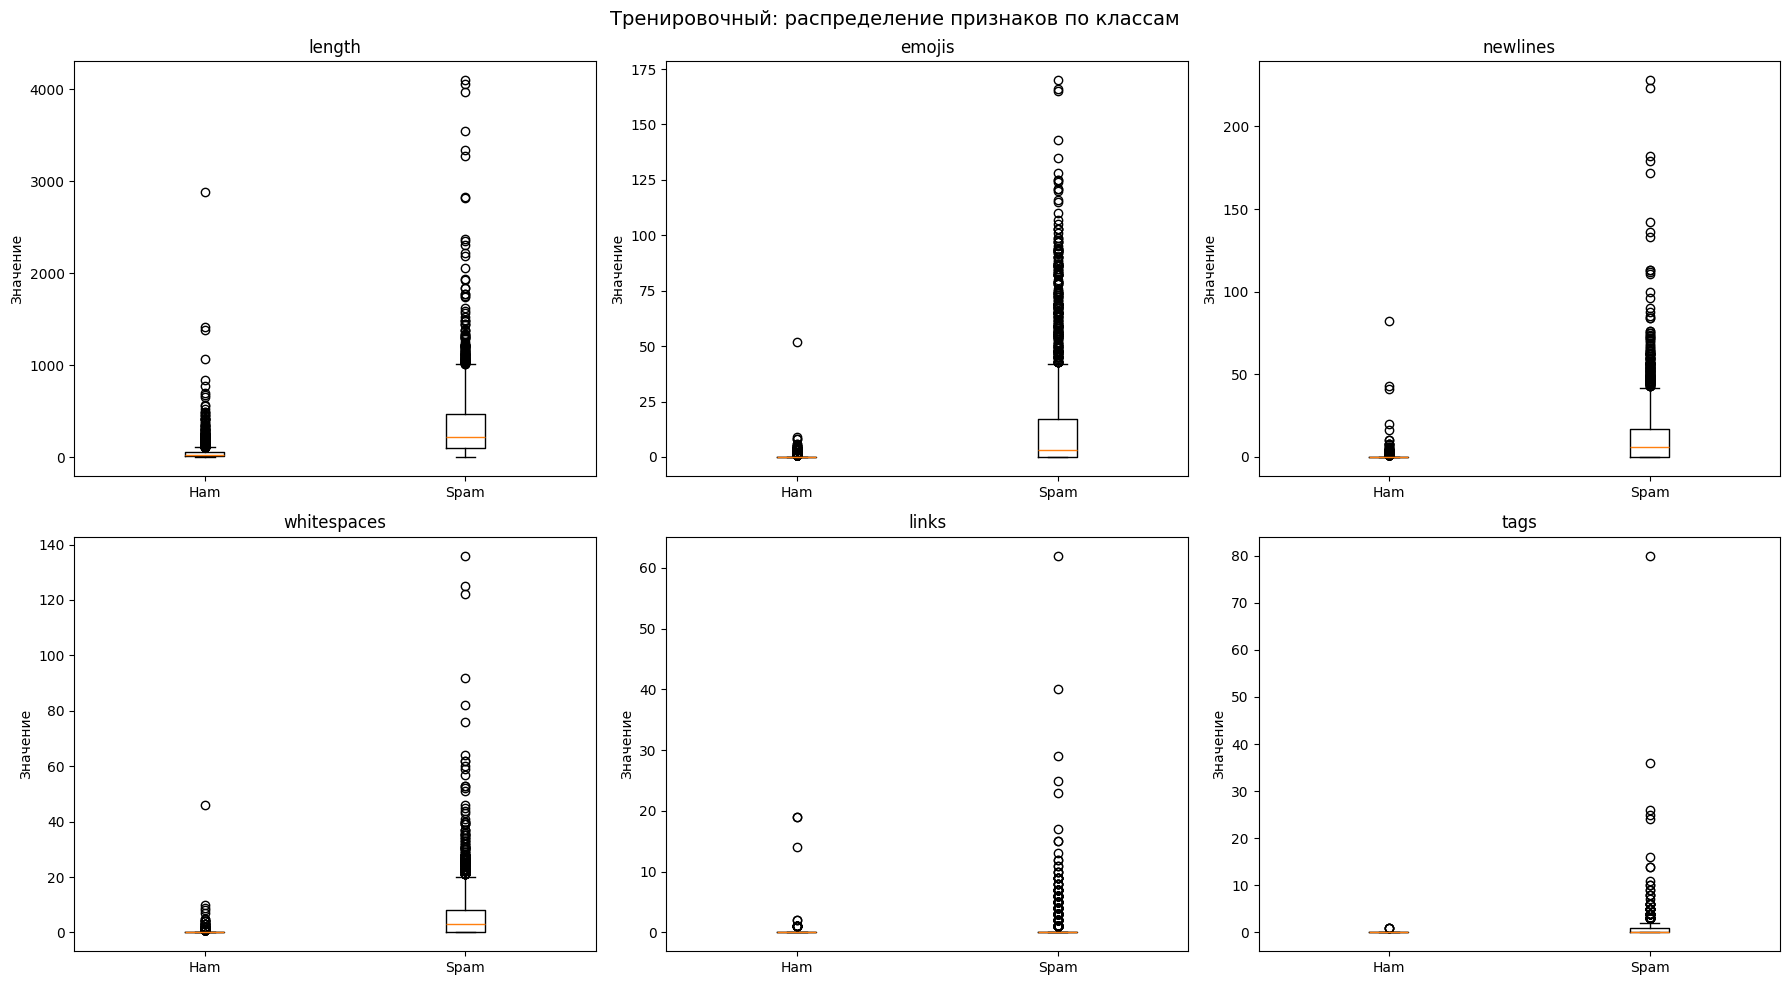

In [30]:
for name, df in [("Тренировочный", df_train)]:
    if df.empty:
        continue
    sample = df.sample(min(5000, len(df)), random_state=42)
    features = pd.DataFrame([compute_features(t) for t in sample['text']])
    features['label'] = sample['label'].values

    feature_cols = ['length', 'emojis', 'newlines', 'whitespaces', 'links', 'tags']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, col in enumerate(feature_cols):
        ax = axes[idx]
        ham_data = features[features['label'] == 0][col]
        spam_data = features[features['label'] == 1][col]
        ax.boxplot([ham_data, spam_data], tick_labels=['Ham', 'Spam'])
        ax.set_title(f'{col}')
        ax.set_ylabel('Значение')

    plt.suptitle(f'{name}: распределение признаков по классам', fontsize=14)
    plt.tight_layout()
    plt.show()

## 10. Корреляционная матрица

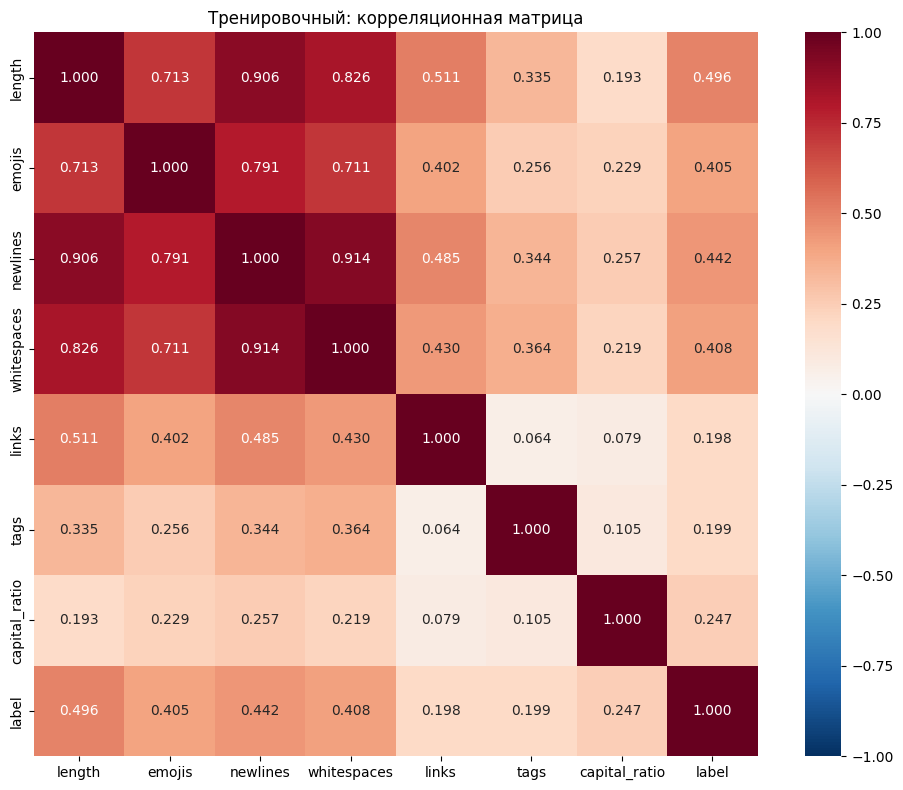


Корреляция признаков с label:
            length: +0.496 (умеренная)
          newlines: +0.442 (умеренная)
       whitespaces: +0.408 (умеренная)
            emojis: +0.405 (умеренная)
     capital_ratio: +0.247 (слабая)
              tags: +0.199 (слабая)
             links: +0.198 (слабая)


In [31]:
for name, df in [("Тренировочный", df_train)]:
    if df.empty:
        continue
    sample = df.sample(min(5000, len(df)), random_state=42)
    features = pd.DataFrame([compute_features(t) for t in sample['text']])
    features['label'] = sample['label'].values

    corr = features.corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                square=True, ax=ax, vmin=-1, vmax=1)
    ax.set_title(f'{name}: корреляционная матрица')
    plt.tight_layout()
    plt.show()

    print(f"\nКорреляция признаков с label:")
    label_corr = corr['label'].drop('label').sort_values(ascending=False)
    for feat, val in label_corr.items():
        strength = "сильная" if abs(val) > 0.5 else "умеренная" if abs(val) > 0.3 else "слабая"
        print(f"  {feat:>16}: {val:+.3f} ({strength})")

## 11. Итоговый отчёт

In [32]:
issues = []

In [33]:
if not df_train.empty:
    ham = len(df_train[df_train['label'] == 0])
    spam = len(df_train[df_train['label'] == 1])
    if ham > 0:
        ratio = max(ham, spam) / min(ham, spam)
        if ratio > 2:
            issues.append(f"Сильный дисбаланс классов: {ratio:.1f}x")

    if train_dupes and train_dupes > 0:
        issues.append(f"Дубликаты в train: {train_dupes}")

    null_count = df_train['text'].isna().sum()
    if null_count > 0:
        issues.append(f"NaN значения в train: {null_count}")

    short_count = (df_train['text'].str.len() < 5).sum()
    if short_count > 0:
        issues.append(f"Очень короткие тексты (<5 символов) в train: {short_count}")

In [34]:
if not df_train.empty and not df_test.empty:
    train_texts = set(df_train['text'].tolist())
    test_texts = set(df_test['text'].tolist())
    overlap = len(train_texts & test_texts)
    if overlap > 0:
        issues.append(f"Data leakage: {overlap} пересечений train/test")

In [35]:
if issues:
    print("\nОбнаруженные проблемы:")
    for i, issue in enumerate(issues, 1):
        print(f"  {i}. {issue}")
else:
    print("\nСерьёзных проблем не обнаружено.")


Обнаруженные проблемы:
  1. Очень короткие тексты (<5 символов) в train: 582
